In [1]:
# ============================================
# DATAPULSE — Phase 4 : Machine Learning
# Classification du genre musical
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Charger les données propres
df = pd.read_csv('data/clean/spotify_clean.csv')

print("Donnees chargees !")
print(f"Shape : {df.shape}")
print(f"Genres : {df['track_genre'].nunique()}")

Donnees chargees !
Shape : (89740, 21)
Genres : 113


In [2]:
# === PRÉPARATION DES DONNÉES ===

# Features audio utilisées pour la classification
features = ['energy', 'danceability', 'valence', 'tempo',
            'acousticness', 'instrumentalness', 'loudness',
            'speechiness', 'liveness']

# On garde seulement les top 10 genres pour simplifier
# (113 genres c'est trop complexe pour commencer)
top10_genres = (df.groupby('track_genre')['popularity']
                .mean().nlargest(10).index.tolist())

df_ml = df[df['track_genre'].isin(top10_genres)].copy()

print(f"Dataset ML : {df_ml.shape[0]:,} morceaux")
print(f"Genres retenus : {df_ml['track_genre'].nunique()}")
print(f"\nGenres : {sorted(df_ml['track_genre'].unique())}")

# Séparer X (features) et y (cible)
X = df_ml[features]
y = df_ml['track_genre']

# Encoder les labels (texte → chiffres)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"\n Classes encodées :")
for i, genre in enumerate(le.classes_):
    print(f"   {i} → {genre}")

Dataset ML : 7,419 morceaux
Genres retenus : 10

Genres : ['anime', 'chill', 'emo', 'grunge', 'indian', 'k-pop', 'latino', 'metal', 'pop-film', 'sad']

 Classes encodées :
   0 → anime
   1 → chill
   2 → emo
   3 → grunge
   4 → indian
   5 → k-pop
   6 → latino
   7 → metal
   8 → pop-film
   9 → sad


In [3]:
# === ENTRAÎNEMENT DU MODÈLE ===

from sklearn.preprocessing import StandardScaler

# Normalisation des features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Séparation train / test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded  # Garder les proportions de chaque genre
)

print(f" Entraînement : {X_train.shape[0]:,} morceaux")
print(f" Test         : {X_test.shape[0]:,} morceaux")

# Entraîner le Random Forest
print("\n Entraînement en cours...")

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1  # Utilise tous les cœurs du CPU
)
rf.fit(X_train, y_train)

# Évaluation
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nModele entraine !")
print(f"Accuracy : {accuracy:.2%}")

 Entraînement : 5,935 morceaux
 Test         : 1,484 morceaux

 Entraînement en cours...

Modele entraine !
Accuracy : 46.43%


 Rapport de classification :

              precision    recall  f1-score   support

       anime       0.57      0.48      0.52       199
       chill       0.46      0.54      0.50       195
         emo       0.38      0.32      0.35       186
      grunge       0.51      0.76      0.61       172
      indian       0.41      0.41      0.41       147
       k-pop       0.44      0.48      0.46       183
      latino       0.54      0.50      0.52        80
       metal       0.57      0.09      0.15        46
    pop-film       0.43      0.46      0.45       163
         sad       0.39      0.27      0.32       113

    accuracy                           0.46      1484
   macro avg       0.47      0.43      0.43      1484
weighted avg       0.46      0.46      0.45      1484



FileNotFoundError: [Errno 2] No such file or directory: '../data/viz_confusion_matrix.png'

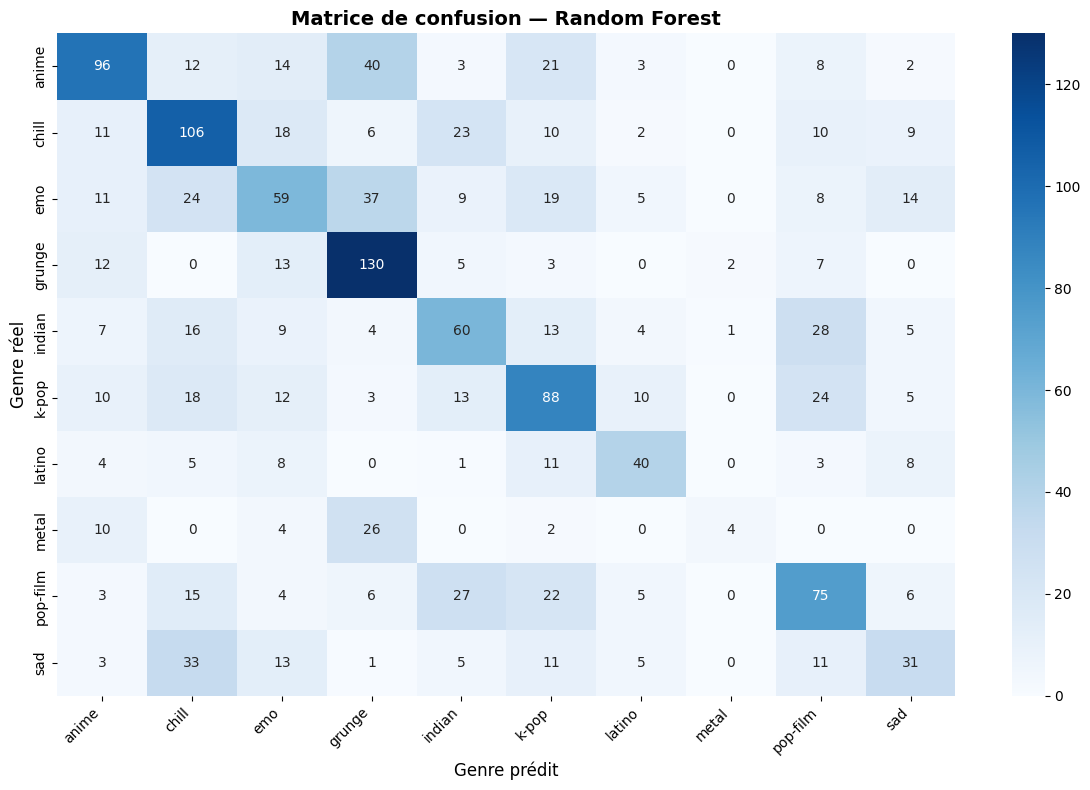

In [4]:
# === ÉVALUATION DÉTAILLÉE ===

# Rapport de classification
print(" Rapport de classification :\n")
print(classification_report(y_test, y_pred, 
                             target_names=le.classes_))

# Matrice de confusion
plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Matrice de confusion — Random Forest', 
          fontsize=14, fontweight='bold')
plt.xlabel('Genre prédit', fontsize=12)
plt.ylabel('Genre réel', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/viz_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Matrice sauvegardée !")

In [ ]:
# === IMPORTANCE DES FEATURES ===

importances = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(importances['feature'], importances['importance'],
                color=plt.cm.viridis(
                    [i/len(features) for i in range(len(features))]
                ))

plt.xlabel('Importance', fontsize=12)
plt.title('Quelles features aident le plus à prédire le genre ?',
          fontsize=14, fontweight='bold')

for bar, val in zip(bars, importances['importance']):
    plt.text(bar.get_width() + 0.001, 
             bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()
print("\nFeature la plus importante :", 
      importances.iloc[-1]['feature'])